# Individual Test Run Recon

Analyse the full `transactions` table for a single test execution.

---
## 1. Init

Modify `RESULTS_BASE_DIR` to traverse through subfolders

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from faultlab.analysis import (
    load_csv,
    enrich_latency_metrics,
    describe_latency_percentiles,
    execution_summary,
    status_summary,
    LATENCY_COLS,
    TERMINAL_STATUSES,
)

sns.set_theme(style="whitegrid")

PROJECT_ROOT_DIR = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT_DIR.joinpath("src")))

RESULTS_BASE_DIR = "results/THROUGHPUT"
# RESULTS_BASE_DIR = "results/GRPC_CONCURRENCY_LIMIT/1"

RESULTS_DIR = PROJECT_ROOT_DIR.joinpath("tests").joinpath(RESULTS_BASE_DIR)

print(f"Results dir  : {RESULTS_DIR}")

Results dir  : /Users/kr1sel/Documents/Code/|_MSC_Proj_|/faultlab/tests/results/THROUGHPUT


---
### 2. Load File

Set `FILE_NAME` variable

In [5]:
FILE_NAME = "test_baseline_10000_txs_10_accounts_20260628_095221.csv"

CSV_FILE = RESULTS_DIR.joinpath(f"{FILE_NAME}{"" if FILE_NAME.endswith(".csv") else ".csv"}")
assert CSV_FILE and CSV_FILE.exists(), f"File not found: {CSV_FILE}"

In [6]:
df = load_csv(CSV_FILE)

print(f"Loaded {len(df)} rows from {CSV_FILE.name}")
display(df.head(5))

Loaded 10000 rows from test_baseline_10000_txs_10_accounts_20260628_095221.csv


,id,amount_ether,confirmed_at,created_at,error_message,failed_at,first_fault_at,from_address,hash,mined_block,...,sweeper_signing_retries,to_address,trace_id,updated_at,version,signing_latency_s,pure_signing_latency_s,submission_latency_s,confirmation_latency_s,e2e_latency_s
0,14ed716f-e4f4-41fe-815e-067fcede2dee,0.014043,2026-06-28 07:49:41.567655+00:00,2026-06-28 07:48:54.493035+00:00,NaN,NaT,NaT,0x8497d9e93d6607536ec349ae93dc59534f2aaa3b,0x296deb82ccc99bda5d8ff10202b8ca4a218a4b4a0ba0...,21,...,NaN,0xad3e599661dceeae1882a8e6c29a0984b7d0eb71,882,2026-06-28 07:49:38.292233+00:00,4,17.818863,0.172166,25.978958,3.276799,47.074620
1,0c4beb3c-df8c-42f3-b5c8-9688159449b3,0.867913,2026-06-28 07:50:52.355934+00:00,2026-06-28 07:49:07.127799+00:00,NaN,NaT,NaT,0xf6bd081541e27d3871cd83cbca71c1e78a0a4318,0x98ba7e070f3c2336a5bca13e908dc73b0a9db1f8f7b6...,34,...,NaN,0x8ed1365a2c400c3657aca4c64ca124d5d909fec5,3894,2026-06-28 07:50:41.123361+00:00,4,50.265208,0.123410,43.725620,11.237307,105.228135
2,52d0c8bb-819b-45b9-8399-c30ff14fea9b,0.287373,2026-06-28 07:50:52.355934+00:00,2026-06-28 07:49:07.176316+00:00,NaN,NaT,NaT,0xf6bd081541e27d3871cd83cbca71c1e78a0a4318,0x20a5f071b934cb99b1a3e892482f9cdcc35c808d1c2a...,34,...,NaN,0x8ed1365a2c400c3657aca4c64ca124d5d909fec5,3918,2026-06-28 07:50:41.142043+00:00,4,50.570748,0.167184,43.393451,11.215419,105.179618
3,1cb648c9-4340-4579-9cfc-d1122d350484,0.959079,2026-06-28 07:50:23.409842+00:00,2026-06-28 07:49:01.968483+00:00,NaN,NaT,NaT,0x71edaace19b90e25eaa73af277c62299dced181f,0xb9c64a353987e053671579464e133cc6d36fca6b7abc...,28,...,NaN,0x8ed1365a2c400c3657aca4c64ca124d5d909fec5,2611,2026-06-28 07:50:11.429965+00:00,4,39.258316,0.092938,30.202225,11.980818,81.441359
4,ce66eb0f-f4fa-4d9d-9468-6b653c19771e,0.242234,2026-06-28 07:49:08.242516+00:00,2026-06-28 07:48:50.888072+00:00,NaN,NaT,NaT,0xa19e272f4be741abff8e281dd21afd137afe72b3,0xc22b89722060077e06971b541ccba973d1831f930f30...,14,...,NaN,0x8497d9e93d6607536ec349ae93dc59534f2aaa3b,35,2026-06-28 07:49:03.861153+00:00,4,5.532713,0.295751,7.436607,4.385124,17.354444


---
### 3. Execution Overview

Shows main accumulated test metrics

In [15]:
df = enrich_latency_metrics(df)
df_signed = df[df["signed_at"].notna()].copy()

summary_df = pd.DataFrame.from_dict(execution_summary(df), orient="index", columns=["Value"])
display(summary_df)

,Value
total_txs,10000.000000
confirmed_txs,10000.000000
swept_txs,0.000000
success_rate,100.000000
overall_tps,58.056000
e2e_median_s,131.181391
pure_sign_median_s,0.135276
signing_queue_median_s,59.955198
submission_median_s,55.741444
confirmation_median_s,7.893006


---
### 4. Stage Breakdown

Durations are computed for each pipeline stage:
- **Full signing latency (Including Queue Time)**   — `created_at` -> `signed_at`
- **Pure signing latency (Excluding Queue Time)**   — `signing_started_at` -> `signed_at`
- **Submission latency**                            — `signed_at` -> `submitted_at`
- **Confirmation latency**                          — `submitted_at` -> `confirmed_at`
- **End-to-end latency**                            — `created_at` -> `confirmed_at`

In [11]:
lat_cols = [c for c in LATENCY_COLS if c in df.columns]

display(describe_latency_percentiles(df, TERMINAL_STATUSES).round(4))

,signing_latency_s,pure_signing_latency_s,submission_latency_s,confirmation_latency_s,e2e_latency_s
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,59.9478,0.1489,48.0826,8.5470,116.5774
std,28.3124,0.0814,19.1606,4.2796,44.0144
min,2.4212,0.0727,0.2925,1.1140,8.2007
50%,59.9552,0.1353,55.7414,7.8930,131.1814
75%,84.2617,0.1632,63.6733,10.6245,156.9134
90%,98.1623,0.2077,67.9685,14.8978,164.8201
95%,103.8117,0.2405,70.2364,16.9731,166.2436
99%,108.3984,0.3068,73.2785,20.6364,170.3422
max,109.4292,2.3145,76.3520,31.2780,172.2488


---
### 5. Status Distribution

,count
CONFIRMED,10000
NEW,0
SIGNING,0
SIGNED,0
SUBMITTING,0
IN_MEMPOOL,0
CONFIRMED_SWEEPED,0
FAILED,0
CRYPTOGRAPHIC_ABORT,0
VERIFICATION_ABORT,0


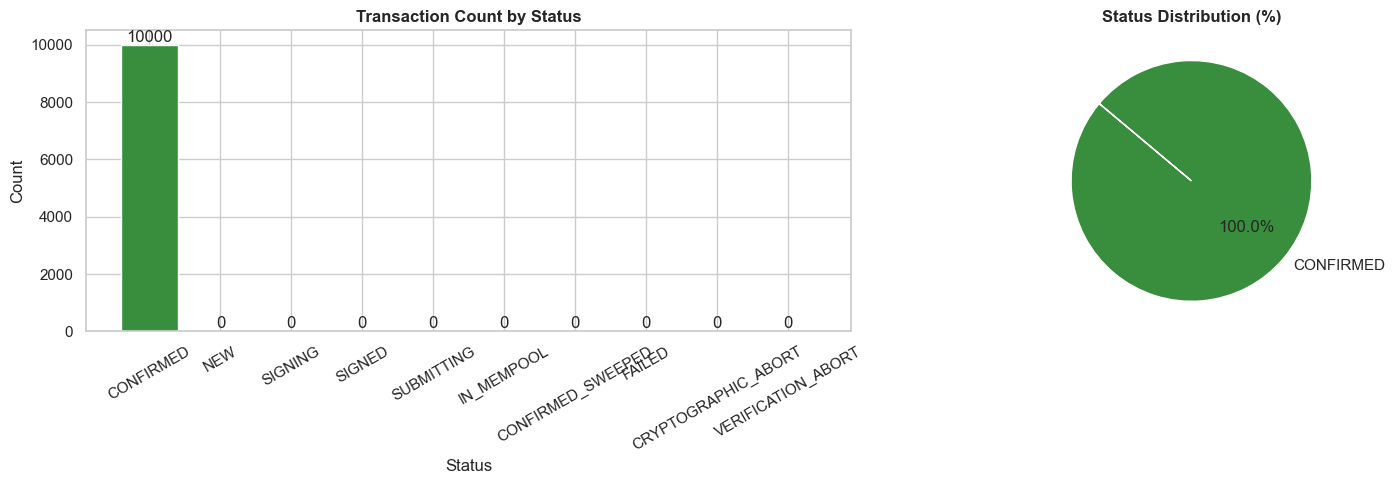

In [ ]:
summary_dict = status_summary(df)

summary = pd.DataFrame.from_dict(summary_dict, orient="index", columns=["count"])

display(summary)

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = ax1.bar(summary.index, summary["count"])
ax1.bar_label(bars, fmt="%d")
ax1.set_title("Transaction Count by Status", fontweight="bold")
ax1.set_xlabel("Status")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=30)

# Pie chart
nonzero = summary[summary["count"] > 0]
ax2.pie(
    nonzero["count"],
    labels=nonzero.index,
    autopct="%1.1f%%",
    startangle=140,
)
ax2.set_title("Status Distribution (%)", fontweight="bold")

plt.tight_layout()
plt.show()

---
### 6. Recovery Analysis 

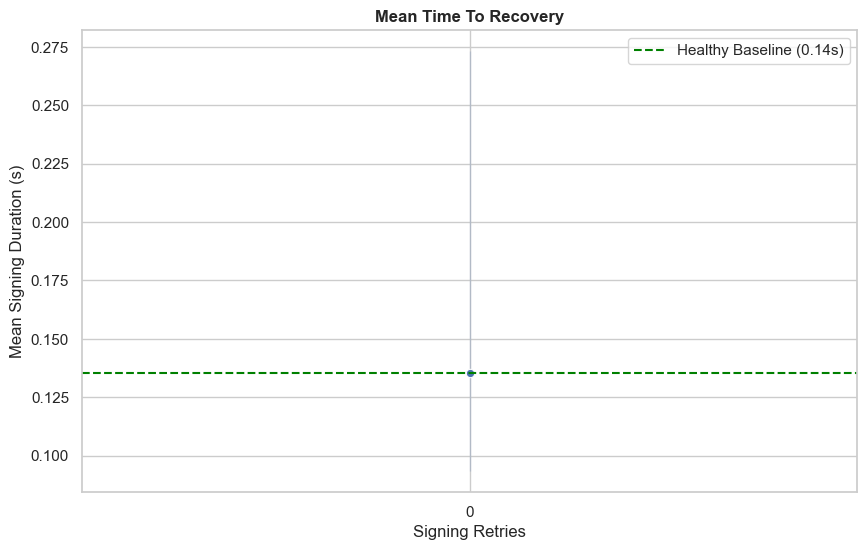

In [16]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_signed,
    x="signing_retries",
    y="pure_signing_latency_s",
    estimator=np.median,
    errorbar=("pi", 95),
    marker="o",
    linewidth=2,
)

zero_retries = df_signed[df_signed["signing_retries"] == 0]
if not zero_retries.empty:
    baseline_median = zero_retries["pure_signing_latency_s"].median()
    plt.axhline(y=baseline_median, color="green", linestyle="--", label=f"Healthy Baseline ({baseline_median:.2f}s)")
    plt.legend()

max_retries = int(df_signed["signing_retries"].max()) if not df_signed.empty else 0
plt.xticks(range(0, max_retries + 1))

plt.title("Mean Time To Recovery", fontweight="bold")
plt.xlabel("Signing Retries")
plt.ylabel("Mean Signing Duration (s)")
plt.show()

---
### 7. State Consistency Analysis

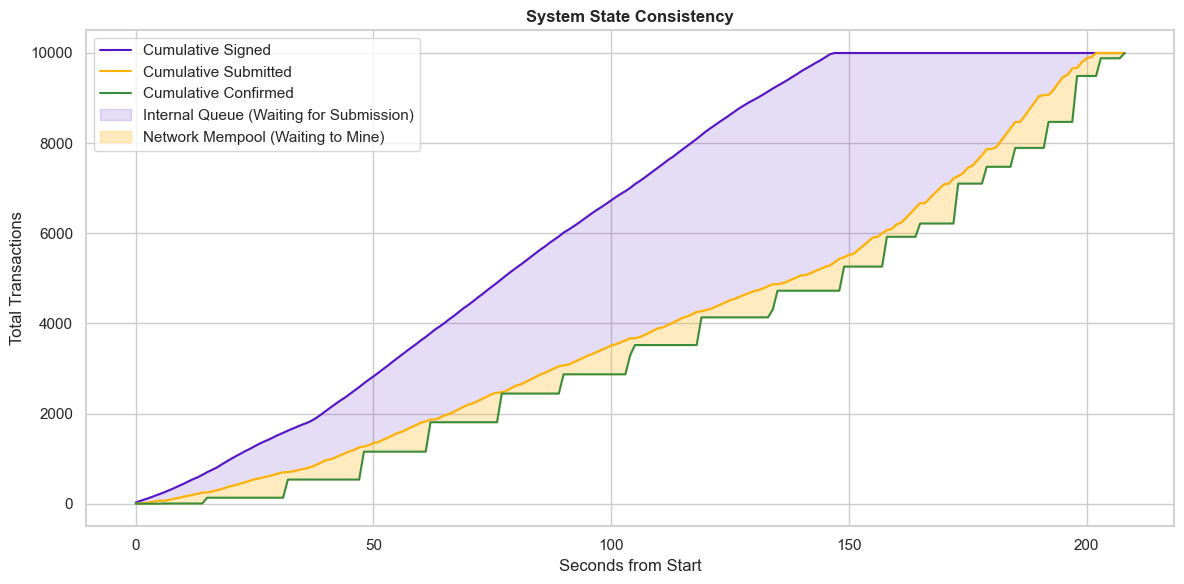

In [17]:
# 1. Normalize timestamps
df["signed_sec"] = pd.to_datetime(df["signed_at"], utc=True).dt.floor("s")
df["submitted_sec"] = pd.to_datetime(df["submitted_at"], utc=True).dt.floor("s")
df["confirmed_sec"] = pd.to_datetime(df["confirmed_at"], utc=True).dt.floor("s")

# 2. Count transactions per second
signed_series = df.groupby("signed_sec")["id"].count()
submitted_series = df.groupby("submitted_sec")["id"].count()
confirmed_series = df.groupby("confirmed_sec")["id"].count()

# 3. Create master timeline
start_time = min(df["signed_sec"].min(), df["submitted_sec"].min(), df["confirmed_sec"].min())
end_time = max(df["signed_sec"].max(), df["submitted_sec"].max(), df["confirmed_sec"].max())
full_timeline = pd.date_range(start=start_time, end=end_time, freq="s")

# 4. Calculate cumulative sums
cumulative_df = pd.DataFrame(index=full_timeline)
cumulative_df["Total Signed"] = signed_series.reindex(full_timeline, fill_value=0).cumsum()
cumulative_df["Total Submitted"] = submitted_series.reindex(full_timeline, fill_value=0).cumsum()
cumulative_df["Total Confirmed"] = confirmed_series.reindex(full_timeline, fill_value=0).cumsum()

# 5. Convert to relative time
cumulative_df["seconds_from_start"] = (cumulative_df.index - start_time).total_seconds()

# 6. Plotting
plt.figure(figsize=(12, 6))

# The three boundary lines
plt.plot(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Signed"],
    color="#5614c7",
    label="Cumulative Signed",
)
plt.plot(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Submitted"],
    color="#ffb300",
    label="Cumulative Submitted",
)
plt.plot(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Confirmed"],
    color="#388e3c",
    label="Cumulative Confirmed",
)

# Fill 1: Internal Java Queue
plt.fill_between(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Submitted"],
    cumulative_df["Total Signed"],
    color="#5614c7",
    alpha=0.15,
    label="Internal Queue (Waiting for Submission)",
)

# Fill 2: Hardhat Network Mempool
plt.fill_between(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Confirmed"],
    cumulative_df["Total Submitted"],
    color="#ffb300",
    alpha=0.25,
    label="Network Mempool (Waiting to Mine)",
)

plt.title("System State Consistency", fontweight="bold")
plt.xlabel("Seconds from Start")
plt.ylabel("Total Transactions")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()